# Grad-CAM Explanations - Skin Disease Classifier

Visualises **where** the trained model looks when it classifies a skin image,
by overlaying a Grad-CAM heatmap on the input. Bright (red) regions are the
areas that most drove the prediction.

Loads your trained `best.pth` (the one Step 7 of the training notebook saved to
Google Drive). A GPU is **not** required - Grad-CAM is light.

---
### Workflow
1. Pull in the project code (`src/`)
2. Install dependencies
3. Load the trained model (from Google Drive, or upload `best.pth`)
4. Explain images you upload
5. (Optional) Grad-CAM on random dataset samples

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Get the project code

Clones the repo so `src/` (including the new `gradcam` module) is importable.

In [2]:
REPO_URL = 'https://github.com/Ammar8065/Skin-Disease-Classification.git'
PROJECT_DIR = '/content/skin-disease'

import os, sys, shutil, subprocess

os.chdir('/content')  # avoid 'cannot read cwd' if a prior run left us inside PROJECT_DIR
if os.path.exists(PROJECT_DIR):
    shutil.rmtree(PROJECT_DIR)
result = subprocess.run(
    ['git', 'clone', '--depth', '1', REPO_URL, PROJECT_DIR],
    capture_output=True, text=True,
)
print(result.stdout); print(result.stderr)
if result.returncode != 0 or not os.path.isdir(PROJECT_DIR):
    raise RuntimeError(f'git clone failed (exit {result.returncode}). See output above.')

os.chdir(PROJECT_DIR)
sys.path.insert(0, PROJECT_DIR)
print('Working dir:', os.getcwd())


Cloning into '/content/skin-disease'...

Working dir: /content/skin-disease


## 2. Install dependencies

In [3]:
!pip install -q -r requirements.txt

## 3. Load the trained model

**Option A - from Google Drive (recommended):** the training notebook saved
`best.pth` to `MyDrive/skin-disease-model/`. Mount Drive and point at it.

**Option B - upload:** set `USE_DRIVE = False` and upload `best.pth` when prompted.

In [4]:
USE_DRIVE = True
CKPT_PATH = '/content/drive/MyDrive/skin-disease-model/best.pth'

import os
if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    assert os.path.exists(CKPT_PATH), f'Checkpoint not found at {CKPT_PATH}'
else:
    from google.colab import files
    up = files.upload()
    CKPT_PATH = list(up.keys())[0]
print('Using checkpoint:', CKPT_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using checkpoint: /content/drive/MyDrive/skin-disease-model/best.pth


In [5]:
from src.inference import SkinDiseaseGradCAM

explainer = SkinDiseaseGradCAM(CKPT_PATH)
print('Loaded model. Device:', explainer.device)
print('Classes:', len(explainer.class_names))

Loaded model. Device: cuda
Classes: 22


In [ ]:
import matplotlib.pyplot as plt

def show_explanation(result, true_label=None):
    """Plot input | Grad-CAM heatmap | overlay for one explanation result."""
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(result['image']); axes[0].set_title('Input')
    axes[1].imshow(result['cam'], cmap='jet'); axes[1].set_title('Grad-CAM')
    axes[2].imshow(result['overlay']); axes[2].set_title('Overlay')
    for ax in axes:
        ax.axis('off')
    title = f"Predicted: {result['label']}  ({result['probability']:.1%})"
    if true_label is not None:
        title += f"   |   True: {true_label}"
    fig.suptitle(title, fontsize=13)
    plt.tight_layout(); plt.show()

## 5. (Optional) Grad-CAM on random dataset samples

Downloads the dataset (cached if already present) and runs Grad-CAM on a few
random images per class, so you can see the heatmaps with known ground truth.

In [9]:
# Provide Kaggle creds (env vars / Colab secrets) - same as the training notebook.
import os
os.environ.setdefault('KAGGLE_USERNAME', 'your_username')  # <-- edit locally, don't commit
os.environ.setdefault('KAGGLE_KEY', 'your_key')            # <-- edit locally, don't commit

import kagglehub
DATA_DIR = kagglehub.dataset_download('pacificrm/skindiseasedataset')
print('Dataset at:', DATA_DIR)

Using Colab cache for faster access to the 'skindiseasedataset' dataset.
Dataset at: /kaggle/input/skindiseasedataset


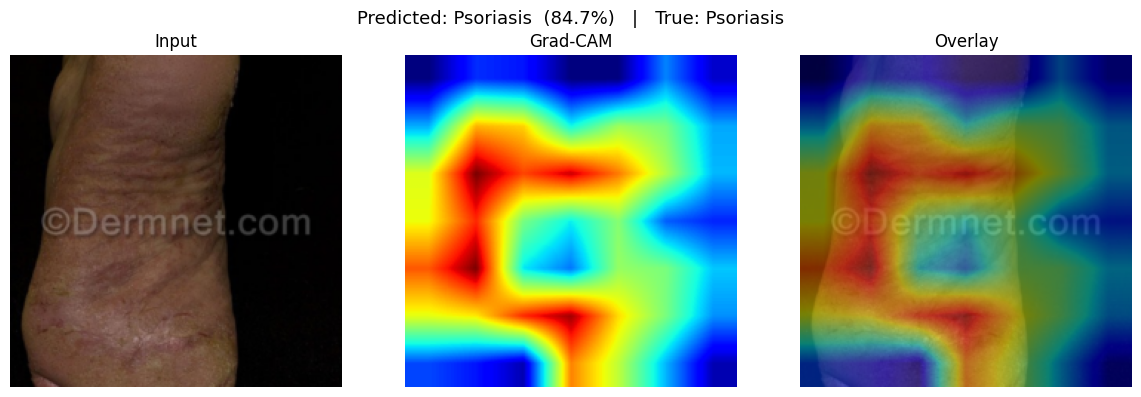

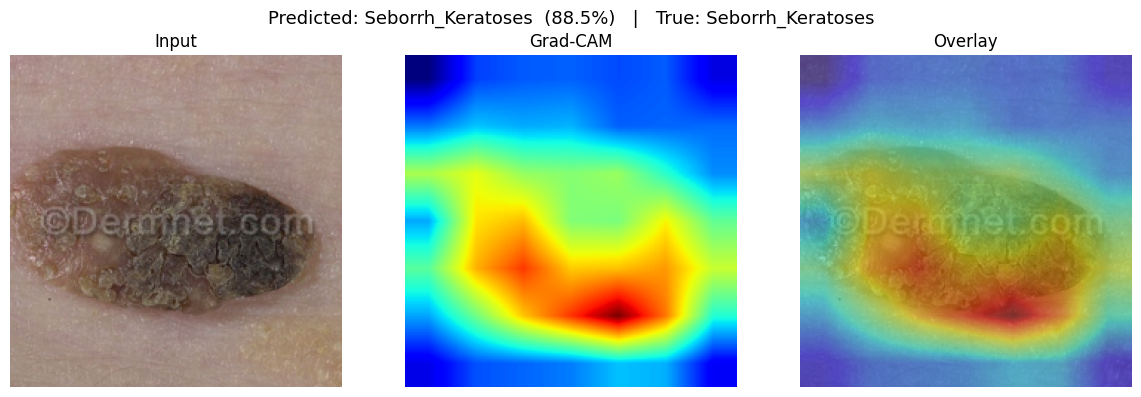

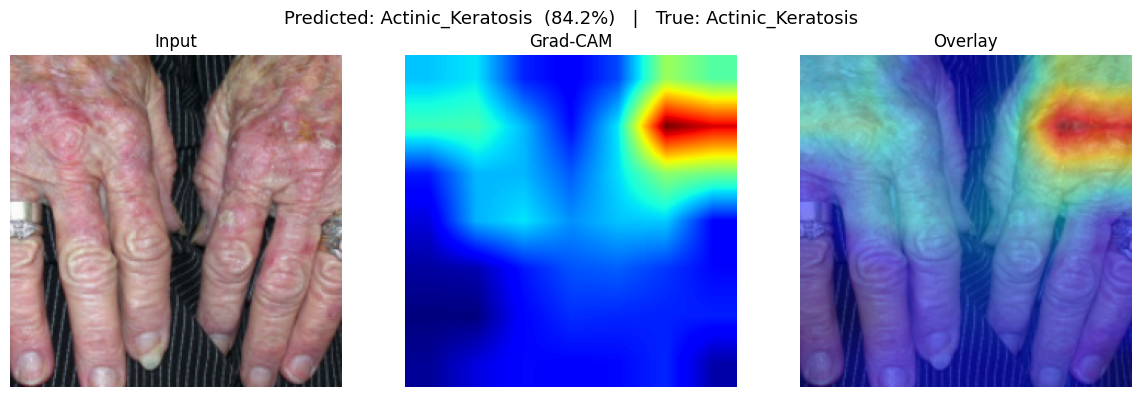

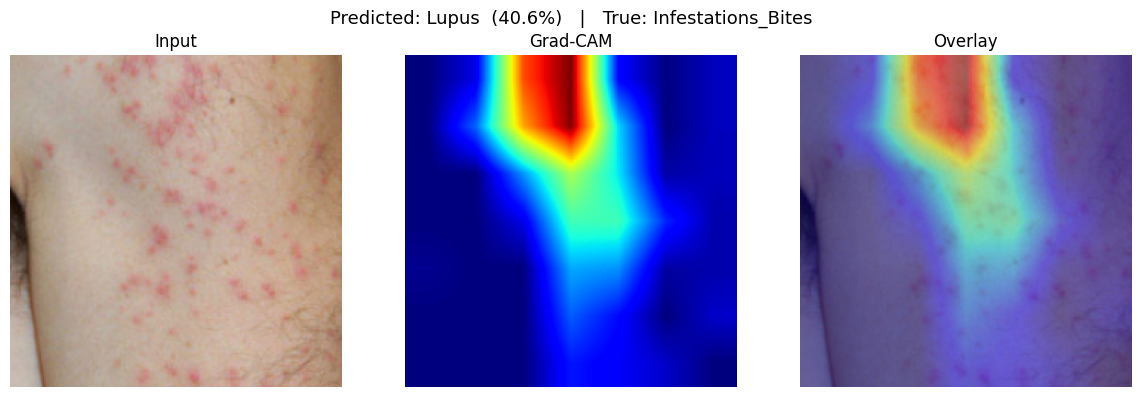

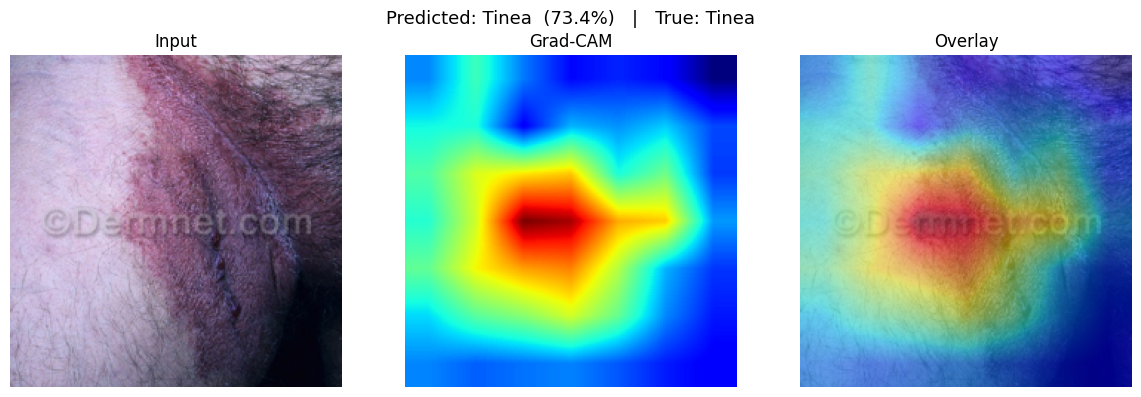

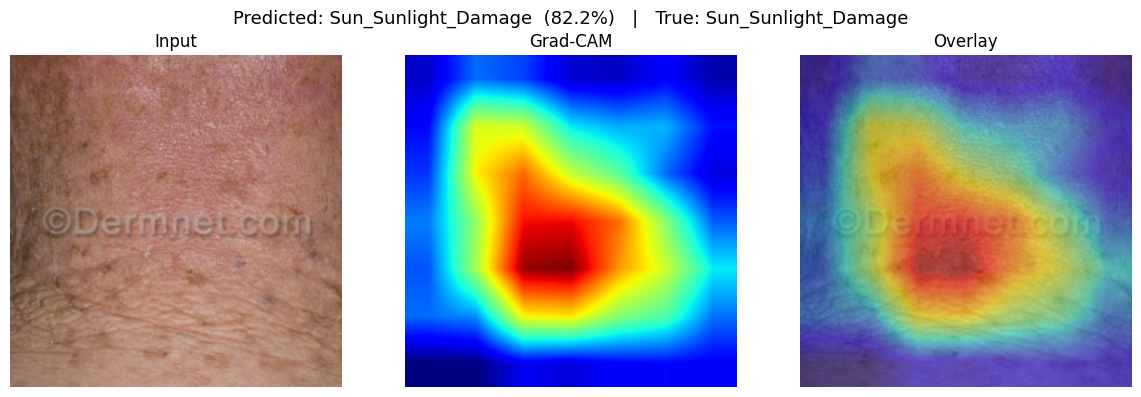

In [10]:
import random, glob
from pathlib import Path
from src.data import SkinDiseaseDataModule

# Reuse the data module just to resolve the image root + class folders.
dm = SkinDiseaseDataModule(data_dir=DATA_DIR)
dm.setup()

# Grab the underlying ImageFolder samples (path, class_idx).
base = dm.test_dataset
while hasattr(base, 'dataset'):
    base = base.dataset
samples = base.samples  # list of (path, class_index)

random.seed(0)
for path, cls in random.sample(samples, 6):
    result = explainer.explain(path)
    show_explanation(result, true_label=base.classes[cls])